# Putting it all together

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.__version__

'2.13.0+cu132'

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [3]:
# prepare data

weight = 0.7
bias = 0.3

# features, labels
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X[:5], y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [4]:
train_split = int(0.8 * len(X))
train_split

40

In [5]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.scatter(train_data, train_labels, s=4, c='coral', label='Training data')
    plt.scatter(test_data, test_labels, s=4, c='blue', label='Testing data')
    if predictions is not None:
        plt.scatter(test_data, predictions, s=4, c='black', label='Predictions')

    plt.legend(prop={'size': 12})

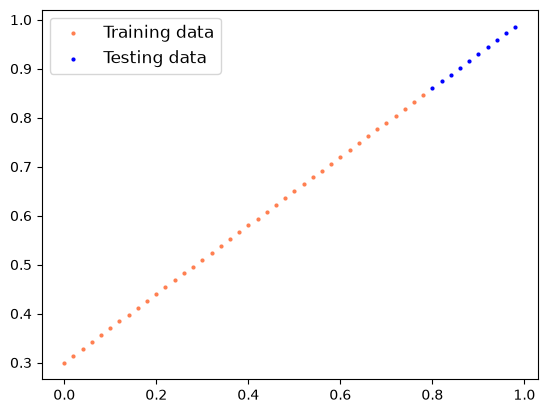

In [7]:
plot_predictions(X_train, y_train, X_test, y_test)

In [8]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # use nn.Linear() for creating the model parameters
        # we don't initialize by ourselves, but we initialize a layer and use the layer for computation
        # also called: linear transform, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [9]:
# one feature shape in, one out
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [10]:
torch.manual_seed(42)
model_2 = LinearRegressionModelV2()
model_2, model_2.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [11]:
next(model_2.parameters()).device

device(type='cpu')

In [12]:
model_2.to(device)
next(model_2.parameters()).device

device(type='cuda', index=0)

# Training

we need:
- loss function
- optimizer
- training loop
- testing loop

In [13]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [14]:
# put data on the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [15]:
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
    model_2.train()

    # forward pass
    y_pred = model_2.forward(X_train)

    # calculate loss
    loss = loss_fn(y_pred, y_train)

    # optimizer zero grad
    optimizer.zero_grad()

    # backpropagation
    loss.backward()

    # calculate gradient / optimizer step
    optimizer.step()

    ### testing
    model_2.eval()

    with torch.inference_mode():
        test_pred = model_2(X_test)
        test_loss = loss_fn(test_pred, y_test)

    # print out what's happening
    if epoch % 10 == 0:
        print(f'Epoch {epoch} | Loss {loss.item()} | Test Loss {test_loss.item()}')

Epoch 0 | Loss 0.5551779270172119 | Test Loss 0.5739762187004089
Epoch 10 | Loss 0.4399681091308594 | Test Loss 0.4392664134502411
Epoch 20 | Loss 0.3247582018375397 | Test Loss 0.30455657839775085
Epoch 30 | Loss 0.20954833924770355 | Test Loss 0.16984669864177704
Epoch 40 | Loss 0.09433844685554504 | Test Loss 0.03513690456748009
Epoch 50 | Loss 0.023886388167738914 | Test Loss 0.04784907028079033
Epoch 60 | Loss 0.019956795498728752 | Test Loss 0.045803118497133255
Epoch 70 | Loss 0.016517987474799156 | Test Loss 0.037530567497015
Epoch 80 | Loss 0.013089174404740334 | Test Loss 0.02994490973651409
Epoch 90 | Loss 0.009653178043663502 | Test Loss 0.02167237363755703
Epoch 100 | Loss 0.006215683650225401 | Test Loss 0.014086711220443249
Epoch 110 | Loss 0.00278724217787385 | Test Loss 0.005814164876937866
Epoch 120 | Loss 0.0012645035749301314 | Test Loss 0.013801801018416882
Epoch 130 | Loss 0.0012645035749301314 | Test Loss 0.013801801018416882
Epoch 140 | Loss 0.001264503574930131

In [16]:
model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [17]:
weight, bias

(0.7, 0.3)

# Making and evaluating predictions

In [18]:
model_2.eval()
with torch.inference_mode():
    y_preds = model_2(X_test)

y_preds[:5]

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157]], device='cuda:0')

In [19]:
y_preds_cpu = y_preds.cpu()
y_preds_cpu[:5]

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157]])

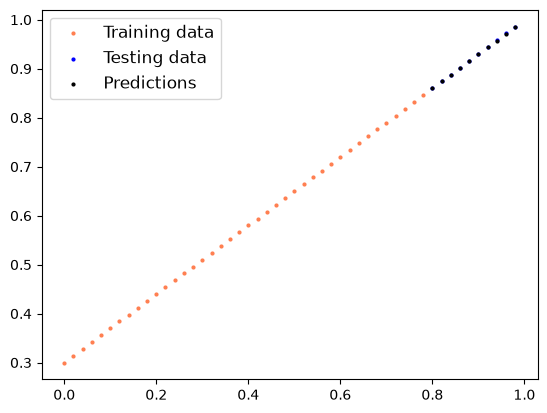

In [20]:
plot_predictions(predictions=y_preds_cpu)

# Save / Load

In [21]:
model_2

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [22]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [23]:
MODEL_NAME = f"03__{model_2._get_name()}"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

WindowsPath('models/03__LinearRegressionModelV2')

In [24]:
print(f"Model state dict saved to: {MODEL_SAVE_PATH}")
torch.save(model_2.state_dict(), MODEL_SAVE_PATH)

Model state dict saved to: models\03__LinearRegressionModelV2


In [25]:
# new instance
loaded_model_2 = LinearRegressionModelV2()

print(f"Loading model state dict from {MODEL_SAVE_PATH}")
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))

# put to target device
loaded_model_2.to(device)

Loading model state dict from models\03__LinearRegressionModelV2


LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [26]:
loaded_model_2, loaded_model_2.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
              ('linear_layer.bias', tensor([0.3025], device='cuda:0'))]))

In [27]:
# Evaluate loaded model

loaded_model_2.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_2(X_test)

y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')